# Alt-Complex-Timing — Deployed Paper System Dashboard

Forward, out-of-sample paper test of the **alt-complex-timing signal** (research FINDINGS Result 9). **PAPER ONLY** — no capital.
Live service `babylon-alt-timing` on the droplet polls the recency-gated timing cohort hourly and logs the breadth tilt; the
book PnL is computed offline (here). This dashboard shows **(1–4)** the in-sample / walk-forward evidence that justified
deployment and **(5–6)** the live forward record as it accumulates.

Regenerate the in-sample artifacts with:
`.venv/bin/python -m research.studies.wallet_flow.alt_timing_dashboard_data`  (then re-run this notebook).

In [1]:
import json, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

ROOT = Path("/Users/corywagamaneure/bablyon")
DASH = ROOT / "data/derived/alt_timing/dashboard"
series = pd.read_parquet(DASH / "series.parquet")
ic = json.loads((DASH / "ic.json").read_text())
summ = json.loads((DASH / "summary.json").read_text())
series["dt"] = pd.to_datetime(series["hour_ms"], unit="ms")
print("cohort", summ["cohort_sha"], "| N", summ["n_wallets"], "| basket", summ["basket"],
      "| usable hours", summ["n_hours"])

cohort 290980281b5c3f4f | N 1500 | basket ['XRP', 'PAXG', 'DOGE', 'SUI', 'BNB', 'LINK', 'AVAX'] | usable hours 7488


In [2]:
# Sync the live forward log from the droplet (best-effort) and keep only current-cohort records.
LIVE = ROOT / "data/follow/alt_timing_live/alt_timing_log.jsonl"
LIVE.parent.mkdir(parents=True, exist_ok=True)
try:
    subprocess.run(["scp", "-o", "BatchMode=yes",
                    "root@167.71.29.107:/root/bablyon/data/follow/alt_timing_live/alt_timing_log.jsonl", str(LIVE)],
                   timeout=30, check=False)
except Exception as e:
    print("live sync skipped:", e)

live = pd.DataFrame()
if LIVE.exists() and LIVE.stat().st_size > 0:
    recs = [json.loads(l) for l in LIVE.read_text().splitlines() if l.strip()]
    live = pd.DataFrame(recs)
    live = live[live["cohort_sha"] == summ["cohort_sha"]].copy()   # forward window = current cohort only
    if len(live):
        live["dt"] = pd.to_datetime(live["hour_ms"], unit="ms")
        live = live.sort_values("hour_ms").reset_index(drop=True)
print(f"live records (current cohort {summ['cohort_sha']}): {len(live)}")

live records (current cohort 290980281b5c3f4f): 1


## Deployment status

In [3]:
b = summ["book"]; oo = b["oos"]; iss = b["in_sample"]
print(f"cohort_sha        {summ['cohort_sha']}   ({summ['n_wallets']} recency-gated timing wallets)")
print(f"basket            {summ['basket']}   half-spread {b['half_spread_bp']:.2f} bp")
print(f"eligible pool     {summ['eligible_pool']:,} recently-active wallets (placebo universe)")
print(f"as_of (fwd start) {summ['as_of_hour_ms']}   |   prereg: {summ['prereg']}")
print(f"OOS walk-forward book Sharpe  gross {oo['gross_sharpe']:+.2f} | net maker {oo['net_sharpe_maker']:+.2f} "
      f"| top-tier {oo['net_sharpe_toptier']:+.2f} | base {oo['net_sharpe_base']:+.2f}   "
      f"({len(oo['test_months'])} test months, {oo['n_test_hours']} hrs)")
print(f"  (in-sample fit, SELECTION-INFLATED for reference: gross {iss['gross_sharpe']:+.2f}, "
      f"net top-tier {iss['net_sharpe_toptier']:+.2f})")
print(f"live forward hours logged: {len(live)}   (verdict needs >= 6 months / 120 active days)")

cohort_sha        290980281b5c3f4f   (1500 recency-gated timing wallets)
basket            ['XRP', 'PAXG', 'DOGE', 'SUI', 'BNB', 'LINK', 'AVAX']   half-spread 0.90 bp
eligible pool     17,971 recently-active wallets (placebo universe)
as_of (fwd start) 1782770400000   |   prereg: docs/ALT_TIMING_PAPER_PREREG.md
OOS walk-forward book Sharpe  gross -0.93 | net maker -4.52 | top-tier -13.96 | base -21.87   (7 test months, 5062 hrs)
  (in-sample fit, SELECTION-INFLATED for reference: gross +9.12, net top-tier -0.99)
live forward hours logged: 1   (verdict needs >= 6 months / 120 active days)


## 1. Basket book — WALK-FORWARD OOS PnL over time
The honest "PnL over time": each month the cohort is **re-ranked + recency-gated on train-only** and evaluated on the
**held-out** month; months are concatenated. Position = `sign(trailing-{S}h mean tilt)` on the BTC/ETH-neutral 7-name basket;
gross vs net at three fee tiers (half-spread always charged on crossings).

**Read this with section 2.** The *signal* is a real OOS positive at H1 (§2), but the tradeable *book* is **net-negative at
every fee** — the classic cost/turnover wall: monetizing an H1 signal needs near-hourly flips, and the basket spread eats them.
The smoothing-sensitivity sweep (second plot) shows there is **no simple smoothing that turns it net-positive** — light
smoothing is gross-positive but turnover-killed; heavy smoothing (the old H8 config) mis-times the H1 signal into gross-negative.
This is the gap the corrected-design build (KF horizon-matching, per-alt selection, maker path) has to close.

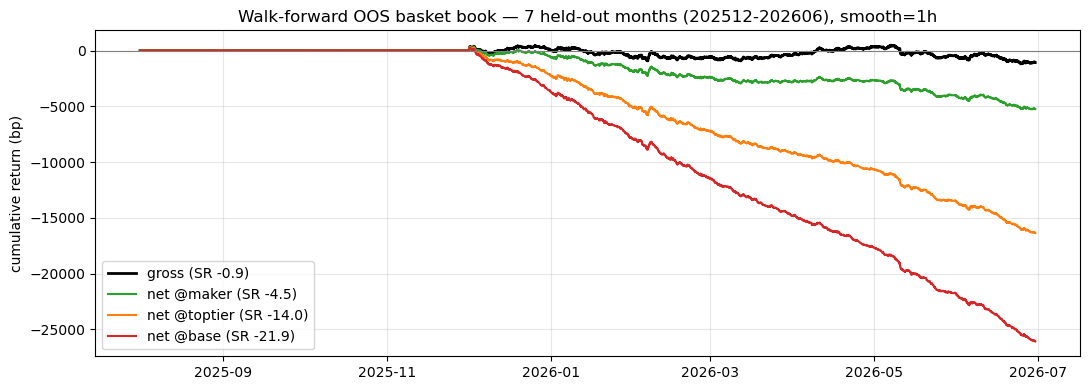

In [4]:
oo = summ["book"]["oos"]
fig, ax = plt.subplots()
ax.plot(series["dt"], series["oos_gross_cum_bp"], label=f"gross (SR {oo['gross_sharpe']:+.1f})", lw=2, color="k")
for name, c in [("maker", "tab:green"), ("toptier", "tab:orange"), ("base", "tab:red")]:
    ax.plot(series["dt"], series[f"oos_net_{name}_cum_bp"],
            label=f"net @{name} (SR {oo[f'net_sharpe_{name}']:+.1f})", color=c)
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("cumulative return (bp)")
ax.set_title(f"Walk-forward OOS basket book — {len(oo['test_months'])} held-out months "
             f"({oo['test_months'][0]}-{oo['test_months'][-1]}), smooth={oo['head_smooth']}h")
ax.legend(); plt.tight_layout(); plt.show()

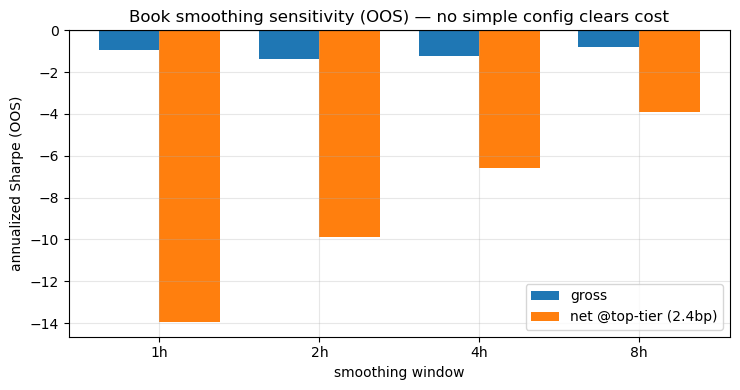

In [5]:
sw = summ["book"]["oos"]["smooth_sweep"]
Ss = sorted(sw, key=int)
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(Ss)); w = 0.38
ax.bar(x - w/2, [sw[s]["gross_sharpe"] for s in Ss], w, label="gross", color="tab:blue")
ax.bar(x + w/2, [sw[s]["net_sharpe_toptier"] for s in Ss], w, label="net @top-tier (2.4bp)", color="tab:orange")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"{s}h" for s in Ss]); ax.set_xlabel("smoothing window")
ax.set_ylabel("annualized Sharpe (OOS)")
ax.set_title("Book smoothing sensitivity (OOS) — no simple config clears cost")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Timing IC — OOS, vs random-recent AND rotation-selected placebos (post-audit, ALT-ONLY)
Does the alt-only tilt predict the forward BTC/ETH-neutral alt-index? **Blue = walk-forward OOS informed.** Grey cloud =
random-recent placebo. **Orange diamond = the rotation-selected placebo** (cohort ranked by alignment with *past* index
momentum, zero forward info) — the audit's decisive control: if it matches blue, the "skill" is passive alt-vs-majors
**rotation loading**, not forward timing. Faint red X = the circular in-sample fit (reference only). Each horizon shows
**two** significance numbers: `z` vs random-recent *selection*, and `t` vs *zero* (the IC's own significance).

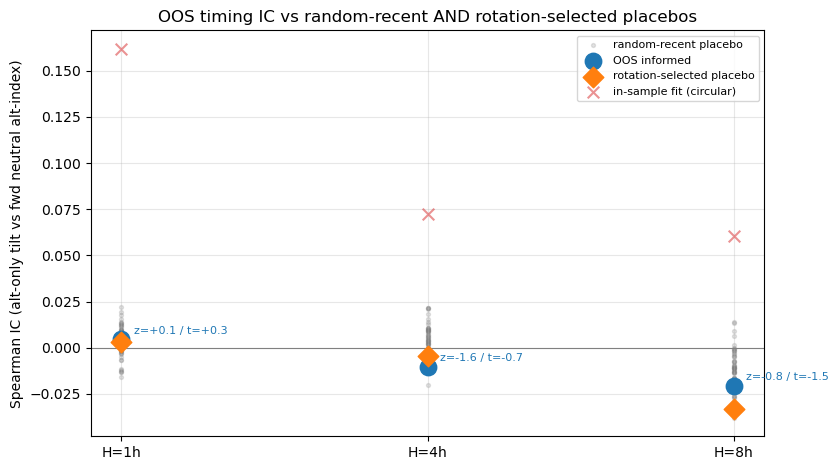

If orange (rotation) ≈ blue (informed), the signal is rotation loading, not skill.


In [6]:
ico, ici = ic["oos"], ic["in_sample"]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
Hs = sorted(ico, key=lambda k: int(k[1:]))
for i, H in enumerate(Hs):
    d = ico[H]; draws = np.array(d["placebo_draws"])
    ax.scatter([i] * len(draws), draws, s=8, alpha=0.22, color="grey", label="random-recent placebo" if i == 0 else None)
    ax.scatter([i], [d["informed_ic"]], s=140, color="tab:blue", zorder=6, label="OOS informed" if i == 0 else None)
    ax.annotate(f"z={d['z_vs_random']:+.1f} / t={d['t_vs_zero']:+.1f}", (i, d["informed_ic"]),
                textcoords="offset points", xytext=(9, 4), color="tab:blue", fontsize=8)
    ax.scatter([i], [d["rotation_ic"]], s=110, marker="D", color="tab:orange", zorder=6,
               label="rotation-selected placebo" if i == 0 else None)
    ax.scatter([i], [ici[H]["informed_ic"]], s=70, marker="x", color="tab:red", alpha=0.5, zorder=4,
               label="in-sample fit (circular)" if i == 0 else None)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(range(len(Hs))); ax.set_xticklabels([f"H={h[1:]}h" for h in Hs])
ax.set_ylabel("Spearman IC (alt-only tilt vs fwd neutral alt-index)")
ax.set_title("OOS timing IC vs random-recent AND rotation-selected placebos")
ax.legend(fontsize=8, loc="best"); plt.tight_layout(); plt.show()
print("If orange (rotation) ≈ blue (informed), the signal is rotation loading, not skill.")

## 3. Recency-gated walk-forward
Per-fold z of the recency-gated cohort (informed vs random-recent), re-ranked each fold. The **honest downgrade**: the
live-harvestable signal is z≈2 (not the ≈4 of the dormant-including cohort), and **weakest in the most recent fold (202606)**.

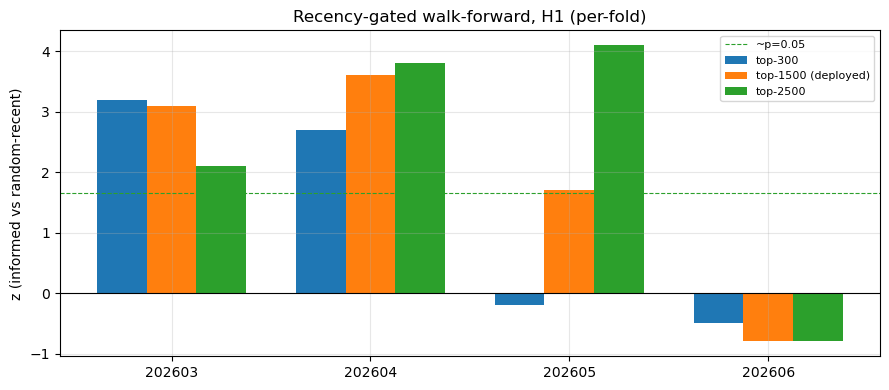

recency-gated (active last 2mo, >=40 alt-h); top-1500 H1 mean z +1.9, top-2500 H1 +2.3; weakest fold 202606


In [7]:
wf = summ["wf_folds"]; folds = wf["folds"]
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(folds)); w = 0.25
for i, (nm, key) in enumerate([("top-300", "top300"), ("top-1500 (deployed)", "top1500"), ("top-2500", "top2500")]):
    z = wf["H1"].get(key)
    if z:
        ax.bar(x + (i - 1) * w, z, w, label=nm)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(1.65, color="tab:green", ls="--", lw=0.8, label="~p=0.05")
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylabel("z (informed vs random-recent)")
ax.set_title("Recency-gated walk-forward, H1 (per-fold)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(wf["note"])

## 4. Cohort liveness — the churn-wall fix
The first freeze (top-150 by all-history mean score) was **dormant** live — its best timers had churned out. The recency gate
(rank among wallets active in the last 2 months) restores a live, pollable cohort.

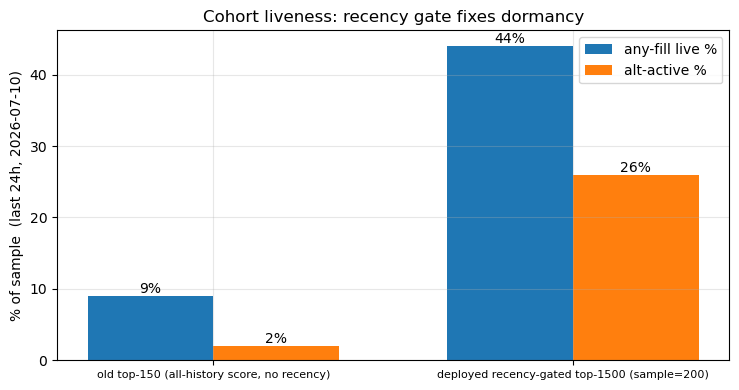

In [8]:
cen = summ["census"]; keys = ["dormant_top150", "recency_top1500"]
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(keys)); w = 0.35
ax.bar(x - w / 2, [cen[k]["live_pct"] for k in keys], w, label="any-fill live %")
ax.bar(x + w / 2, [cen[k]["alt_active_pct"] for k in keys], w, label="alt-active %")
for i, k in enumerate(keys):
    ax.annotate(f"{cen[k]['live_pct']}%", (i - w / 2, cen[k]["live_pct"]), ha="center", va="bottom")
    ax.annotate(f"{cen[k]['alt_active_pct']}%", (i + w / 2, cen[k]["alt_active_pct"]), ha="center", va="bottom")
ax.set_xticks(x); ax.set_xticklabels([cen[k]["label"] for k in keys], fontsize=8)
ax.set_ylabel(f"% of sample  ({cen['window']})")
ax.set_title("Cohort liveness: recency gate fixes dormancy"); ax.legend(); plt.tight_layout(); plt.show()

## 5. Live forward record (accumulating)
Straight from the droplet service log. Fills in one row per hour; the service warms up its 8h buffer first, so the very first
hours may show `tilt=null` / low voter counts.

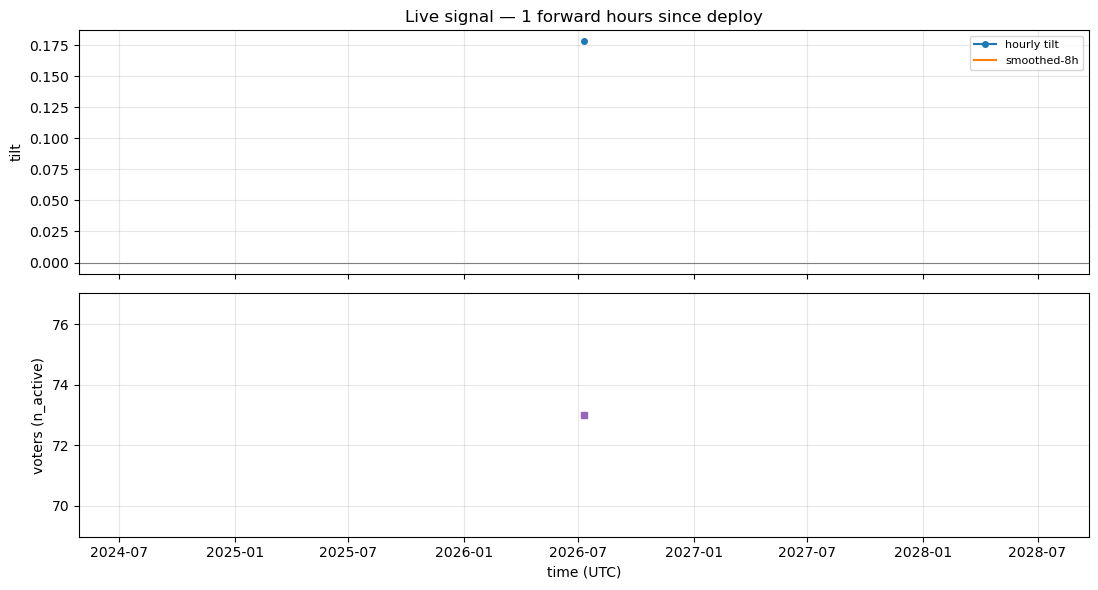

In [9]:
if len(live) >= 1:
    fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axs[0].plot(live["dt"], live["tilt"], marker="o", ms=4, label="hourly tilt")
    if live["smoothed"].notna().any():
        axs[0].plot(live["dt"], live["smoothed"], label="smoothed-8h", color="tab:orange")
    axs[0].axhline(0, color="grey", lw=0.8); axs[0].set_ylabel("tilt"); axs[0].legend(fontsize=8)
    axs[0].set_title(f"Live signal — {len(live)} forward hours since deploy")
    axs[1].plot(live["dt"], live["n_active"], marker="s", ms=4, color="tab:purple")
    axs[1].set_ylabel("voters (n_active)"); axs[1].set_xlabel("time (UTC)")
    plt.tight_layout(); plt.show()
else:
    print("No current-cohort live records yet (service warming up). This panel fills in hourly.")

In [10]:
# PROVISIONAL live paper PnL from logged mids (raw basket, position-weighted). The official mark is the
# BTC/ETH-neutralized book computed at monthly eval; this is a first-look only.
if len(live) >= 2:
    basket = summ["basket"]
    def bret(m0, m1):
        rs = [np.log(float(m1[c]) / float(m0[c])) for c in basket
              if c in m0 and c in m1 and float(m0.get(c, 0)) > 0 and float(m1.get(c, 0)) > 0]
        return float(np.mean(rs)) if rs else np.nan
    pnl = []
    for i in range(len(live) - 1):
        br = bret(live.loc[i, "mids"], live.loc[i + 1, "mids"]); p = float(live.loc[i, "position"])
        pnl.append(p * br if np.isfinite(br) else 0.0)
    cum = np.cumsum(pnl) * 1e4
    fig, ax = plt.subplots()
    ax.plot(live["dt"].iloc[1:], cum, marker="o", ms=4)
    ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("cum PnL (bp)")
    ax.set_title("PROVISIONAL live paper PnL (raw basket, position-weighted — not yet BTC/ETH-neutralized)")
    plt.tight_layout(); plt.show()
else:
    print("Need >= 2 live records for a PnL curve. Accumulating (service warming up).")

Need >= 2 live records for a PnL curve. Accumulating (service warming up).


## What this says / honest caveats
- **The signal is real out-of-sample, but not yet monetizable.** Walk-forward, the cohort tilt beats a random-recent
  placebo at H1 (IC +0.025, **z≈3**) — a genuine, placebo-hardened OOS positive. **But every naive book config is
  net-negative** (§1 sweep): the edge is H1-concentrated, and hourly turnover on a ~1.8bp basket spread eats it. Value of the
  live paper follower = it **logs the raw hourly tilt**, so the *right* book (horizon, sizing, instrument) can be found offline.
- **The in-sample fit is a trap** (§2 red X, z≈24): the cohort was scored to maximise exactly that. Only the OOS blue counts.
- **This is the setup for the corrected-design build**, not a finished strategy: KF horizon-matched scoring, per-alt selection
  (which alts to trade vs the whole basket), the maker path (earn the spread instead of paying it), and the "is it just
  alt-season?" confound — all pending. The dashboard is the instrument to judge whether those close the §1 gap.
- **Verdict rules frozen** in `docs/ALT_TIMING_PAPER_PREREG.md`: min 6 months / 120 active days before any verdict; the live
  forward record (§5–6) is what accumulates the power the 7-month in-sample window can't provide.
- Monthly refresh re-runs `export_timing_cohort.py` (recency gate auto-rolls) → new cohort_sha; forward window restarts per export.